### Load & First Look

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv('final_data_with_changes.csv')

In [5]:
df.shape

(51707, 36)

In [6]:
df.dtypes

price_total                       float64
room_type                          object
is_shared_room                      int64
is_private_room                     int64
max_guests                        float64
is_superhost                        int64
is_multi_listing                    int64
is_business_listing                 int64
cleanliness_score                 float64
guest_satisfaction_score          float64
num_bedrooms                        int64
distance_city_center              float64
distance_metro                    float64
attraction_index                  float64
attraction_index_norm             float64
restaurant_index                  float64
restaurant_index_norm             float64
longitude                         float64
latitude                          float64
city                               object
day_type                           object
district                           object
state                              object
country_code                      

In [7]:
df.head()

,price_total,room_type,is_shared_room,is_private_room,max_guests,is_superhost,is_multi_listing,is_business_listing,cleanliness_score,guest_satisfaction_score,num_bedrooms,distance_city_center,distance_metro,attraction_index,attraction_index_norm,restaurant_index,restaurant_index_norm,longitude,latitude,city,day_type,district,state,country_code,country_name,Crime_Index,Safety_Index,Monthly_Average_Net_salary,Meal_at_Inexpensive_Restaurant,Taxi_price_per_Km,Monthly_Basic_Utilities,Monthly_Rent_One_Bedroom_CC,Monthly_Rent_One_Bedroom_OCC,Monthly_Rent_Three_Bedroom_CC,Monthly_Rent_Three_Bedroom_OCC,proximity_index
0,93.788179,Private room,0,1,2.0,1,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,Amsterdam,weekday,Gemeente Landsmeer,North Holland,NL,Netherlands,25.7,74.3,4502.1,20.5,3.0,262.0,2178.68,1701.26,3725.5,2785.29,0.225448
1,822.169053,Private room,0,1,4.0,1,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,Amsterdam,weekday,Gemeente Amsterdam,North Holland,NL,Netherlands,25.7,74.3,4502.1,20.5,3.0,262.0,2178.68,1701.26,3725.5,2785.29,1.113955
2,104.351833,Private room,0,1,2.0,1,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,Amsterdam,weekday,Gemeente Diemen,North Holland,NL,Netherlands,25.7,74.3,4502.1,20.5,3.0,262.0,2178.68,1701.26,3725.5,2785.29,0.184291
3,1031.986037,Private room,0,1,4.0,1,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,Amsterdam,weekday,Gemeente Amsterdam,North Holland,NL,Netherlands,25.7,74.3,4502.1,20.5,3.0,262.0,2178.68,1701.26,3725.5,2785.29,1.110275
4,1078.983564,Private room,0,1,2.0,0,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,Amsterdam,weekday,Gemeente Amsterdam,North Holland,NL,Netherlands,25.7,74.3,4502.1,20.5,3.0,262.0,2178.68,1701.26,3725.5,2785.29,1.036462


In [8]:
df.describe()

,price_total,is_shared_room,is_private_room,max_guests,is_superhost,is_multi_listing,is_business_listing,cleanliness_score,guest_satisfaction_score,num_bedrooms,distance_city_center,distance_metro,attraction_index,attraction_index_norm,restaurant_index,restaurant_index_norm,longitude,latitude,Crime_Index,Safety_Index,Monthly_Average_Net_salary,Meal_at_Inexpensive_Restaurant,Taxi_price_per_Km,Monthly_Basic_Utilities,Monthly_Rent_One_Bedroom_CC,Monthly_Rent_One_Bedroom_OCC,Monthly_Rent_Three_Bedroom_CC,Monthly_Rent_Three_Bedroom_OCC,proximity_index
count,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.00000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000
mean,368.620987,0.007078,0.361518,3.161661,0.744097,0.291353,0.350204,9.390624,92.628232,1.15876,3.191285,0.681540,294.204105,13.423792,626.856696,22.786177,7.426068,45.671128,46.369834,53.630166,2611.825205,16.499909,1.780522,228.501078,1518.019100,1105.005234,2692.939883,1945.483547,0.597525
std,509.717535,0.083835,0.480445,1.298545,0.436372,0.454390,0.477038,0.954868,8.945531,0.62741,2.393803,0.858023,224.754123,9.807985,497.920226,17.804096,9.799725,5.249263,10.789932,10.789932,1179.745274,3.722901,0.737444,73.984517,700.342853,512.655685,1034.869468,830.160945,0.248780
min,7.657682,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,20.000000,0.00000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757,-9.226340,37.953000,25.700000,42.000000,1164.490000,10.470000,0.900000,134.930000,614.420000,519.210000,1142.700000,946.390000,0.047455
25%,157.537810,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,9.000000,90.000000,1.00000,1.453142,0.248480,136.797385,6.380926,250.854114,8.751480,-0.072500,41.399510,33.900000,44.400000,1410.600000,15.000000,1.150000,184.560000,1280.450000,820.590000,2162.900000,1541.670000,0.432760
50%,260.500210,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,10.000000,95.000000,1.00000,2.613538,0.413269,234.331748,11.468305,522.052783,17.542238,4.873000,47.506690,47.300000,52.700000,2102.820000,15.000000,1.500000,187.370000,1387.500000,1036.000000,2431.820000,1633.330000,0.575571
75%,433.668497,0.000000,1.000000,4.000000,1.000000,1.000000,1.000000,10.000000,99.000000,1.00000,4.263077,0.737840,385.756381,17.415082,832.628988,32.964603,13.518825,51.471885,55.600000,66.100000,3305.140000,18.250000,2.800000,291.200000,1398.590000,1061.180000,3088.460000,2145.000000,0.725286
max,43955.618778,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,10.000000,100.000000,10.00000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000,23.786020,52.641410,58.000000,74.300000,4502.100000,23.010000,3.000000,347.110000,2788.440000,2029.850000,4402.560000,3416.390000,1.820960


### Data Cleaning

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(missing_df)

Empty DataFrame
Columns: [count, pct]
Index: []


In [10]:
duplicated = df.duplicated().sum()
duplicated_pct = (duplicated / len(df)) * 100
print(f"count: {duplicated}, pct: {duplicated_pct}")

count: 0, pct: 0.0


In [11]:
print("Cities    :", sorted(df['city'].unique()))
print("Countries :", sorted(df['country_name'].unique()))
print("Day types :", df['day_type'].unique())
print("Room types:", df['room_type'].unique())

Cities    : ['Amsterdam', 'Athens', 'Barcelona', 'Berlin', 'Budapest', 'Lisbon', 'London', 'Paris', 'Rome', 'Vienna']
Countries : ['Austria', 'France', 'Germany', 'Greece', 'Holy See (Vatican City State)', 'Hungary', 'Italy', 'Netherlands', 'Portugal', 'Spain', 'United Kingdom']
Day types : ['weekday' 'weekend']
Room types: ['Private room' 'Entire home/apt' 'Shared room']


In [12]:
price = df['price_total']

print(f"Mean    : ${price.mean():.2f}")
print(f"Median  : ${price.median():.2f}")
print(f"Std     : ${price.std():.2f}")
print(f"Skew    : {price.skew():.3f}")
print(f"Kurt    : {price.kurtosis():.3f}")
print(f"p1      : ${price.quantile(0.01):.2f}")
print(f"p99     : ${price.quantile(0.99):.2f}")

outlier_pct = ((price < price.quantile(0.01)) | (price > price.quantile(0.99))).mean() * 100
print(f"Outliers: {outlier_pct:.1f}%  (outside p1–p99)")

Mean    : $368.62
Median  : $260.50
Std     : $509.72
Skew    : 25.743
Kurt    : 1527.022
p1      : $35.72
p99     : $1874.58
Outliers: 2.0%  (outside p1–p99)


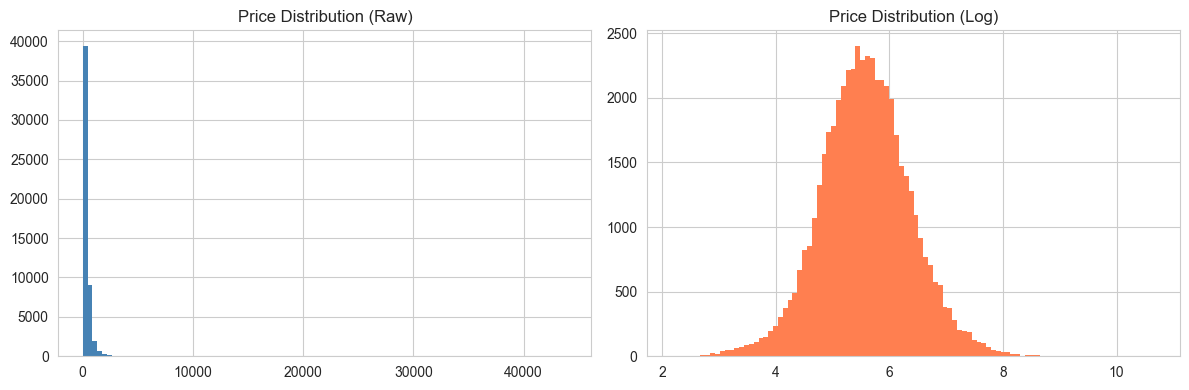

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price_total'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Price Distribution (Raw)')
axes[1].hist(np.log1p(df['price_total']), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Price Distribution (Log)')
plt.tight_layout()
plt.show()

In [14]:
# Outlier capping
cap_99 = df['price_total'].quantile(0.99)
df['price_log'] = np.log1p(df['price_total'].clip(upper=cap_99))

In [15]:
# Normality check on log-price
sample = df['price_total'].sample(min(5000, len(df)), random_state=42)
stat, p = stats.shapiro(np.log1p(sample))
print(f"Shapiro-Wilk on log(price): W={stat:.4f}, p={p:.2e}")
print("→ Recommendation: use price_log as model target" if p < 0.05 else "→ Approximately normal after log transform")


Shapiro-Wilk on log(price): W=0.9966, p=3.03e-09
→ Recommendation: use price_log as model target


### Analysis

               median        mean         std  count
city                                                
Amsterdam  503.228688  713.967073  718.376147   2080
Paris      449.601533  581.605546  514.815259   6688
Lisbon     330.271926  378.870581  263.175615   5763
Barcelona  322.737370  440.353220  457.181311   2833
Budapest   244.577772  295.296524  239.485047   4022
Vienna     243.284266  320.021011  552.131629   3537
London     239.109815  388.030954  760.978229   9993
Berlin     198.314931  269.799894  346.902425   2484
Rome       193.896194  236.034429  176.747085   9027
Athens     181.500068  237.963670  445.684507   5280


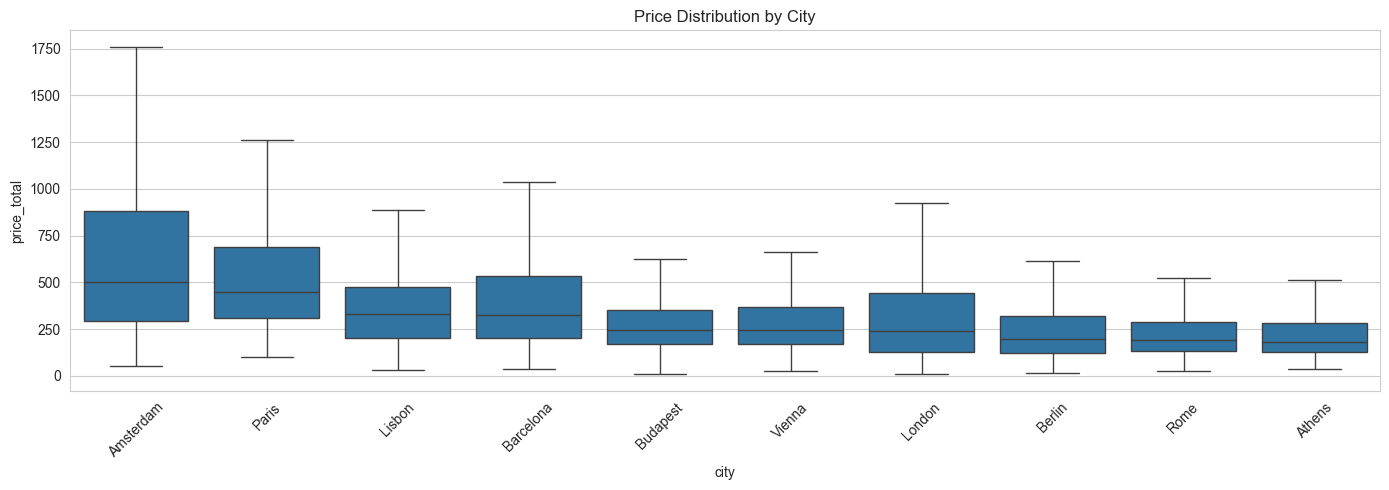

In [16]:
# Price by city
city_stats = df.groupby('city')['price_total'].agg(['median', 'mean', 'std', 'count'])
city_stats = city_stats.sort_values('median', ascending=False)
print(city_stats)

# Visualization
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='city', y='price_total',
            order=city_stats.index,
            showfliers=False)
plt.xticks(rotation=45)
plt.title('Price Distribution by City')
plt.tight_layout()
plt.show()

In [17]:
# Weekend Premium
print(df['day_type'].value_counts())

day_price = df.groupby('day_type')['price_total'].median()
print(day_price)

# Weekend premium?
weekend = df[df['day_type'] == 'weekend']['price_total'].median()
weekday = df[df['day_type'] == 'weekday']['price_total'].median()
print(f"Weekend premium: {(weekend/weekday - 1)*100:.1f}%")

day_type
weekend    26207
weekday    25500
Name: count, dtype: int64
day_type
weekday    253.786066
weekend    265.371261
Name: price_total, dtype: float64
Weekend premium: 4.6%


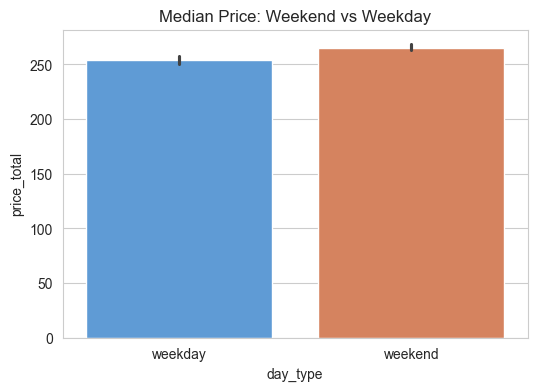

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='day_type',
    y='price_total',
    data=df,
    estimator='median',
    palette=['#4C9BE8', '#E87B4C']
)

plt.title('Median Price: Weekend vs Weekday')
plt.show()

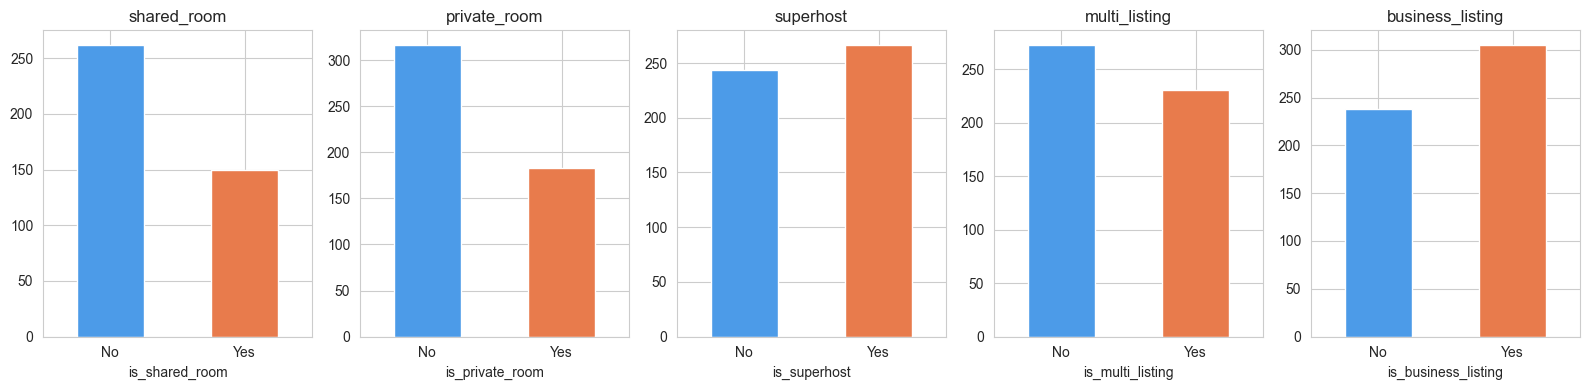

In [19]:
# Binary features analysis
binary_cols = ['is_shared_room', 'is_private_room', 'is_superhost',
               'is_multi_listing', 'is_business_listing']

fig, axes = plt.subplots(1, len(binary_cols), figsize=(16, 4))
for i, col in enumerate(binary_cols):
    df.groupby(col)['price_total'].median().plot(
        kind='bar', ax=axes[i], color=['#4C9BE8', '#E87B4C']
    )
    axes[i].set_title(col.replace('is_', ''))
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Location features
loc_cols = ["distance_city_center","distance_metro",
            "attraction_index_norm","restaurant_index_norm","proximity_index"]

corr_loc = df[loc_cols + ["price_total"]].corr()["price_total"].drop("price_total")
print("Correlation with price_total:")
print(corr_loc.sort_values(ascending=False).round(3).to_string())


Correlation with price_total:
attraction_index_norm    0.389
proximity_index          0.345
restaurant_index_norm    0.301
distance_metro          -0.199
distance_city_center    -0.242


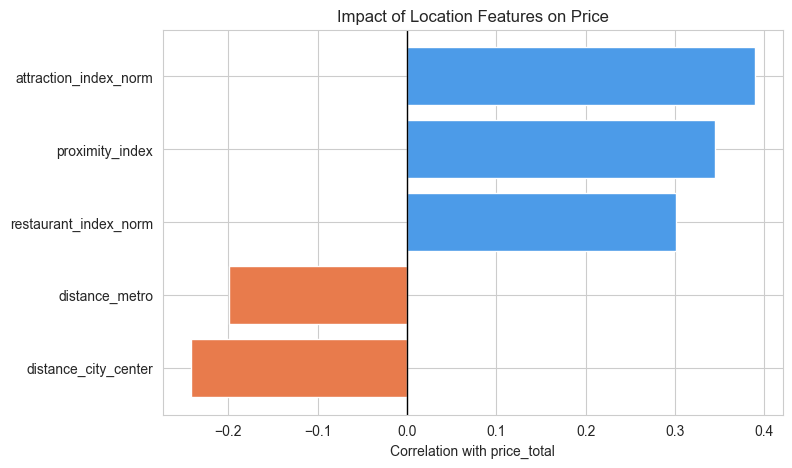

In [21]:
corr_sorted = corr_loc.sort_values()

plt.figure(figsize=(8,5))

plt.barh(
    corr_sorted.index,
    corr_sorted.values,
    color=['#4C9BE8' if x > 0 else '#E87B4C' for x in corr_sorted.values]
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Impact of Location Features on Price')
plt.xlabel('Correlation with price_total')

plt.show()

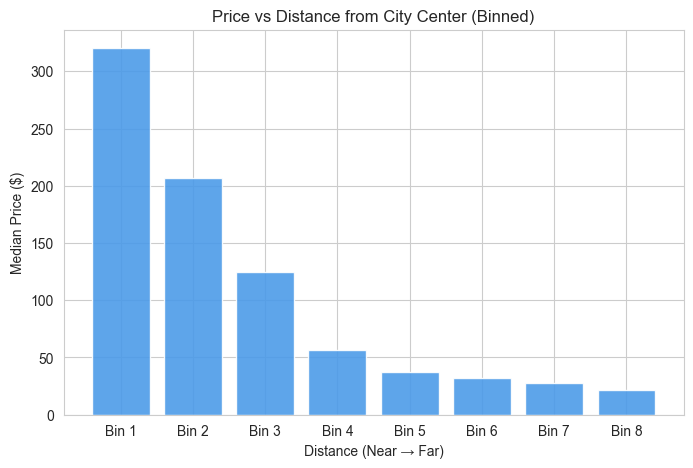

In [22]:
# Create bins
df["dist_bin"] = pd.cut(df["distance_city_center"], bins=8)

# Median price per bin
bin_price = df.groupby("dist_bin")["price_total"].median()

plt.figure(figsize=(8,5))

plt.bar(
    range(len(bin_price)),
    bin_price.values,
    color='#4C9BE8',
    alpha=0.9
)

plt.title("Price vs Distance from City Center (Binned)")
plt.xlabel("Distance (Near → Far)")
plt.ylabel("Median Price ($)")

plt.xticks(range(len(bin_price)), [f"Bin {i+1}" for i in range(len(bin_price))])

plt.show()

# cleanup
df.drop(columns=["dist_bin"], inplace=True, errors="ignore")

In [23]:
# Economic features
econ_cols = [
    "Monthly_Average_Net_salary","Crime_Index","Safety_Index",
    "Meal_at_Inexpensive_Restaurant","Taxi_price_per_Km",
    "Monthly_Basic_Utilities","Monthly_Rent_One_Bedroom_CC",
    "Monthly_Rent_One_Bedroom_OCC","Monthly_Rent_Three_Bedroom_CC",
    "Monthly_Rent_Three_Bedroom_OCC"
]

corr_econ = df[econ_cols + ["price_total"]].corr()["price_total"].drop("price_total")
print("Economic feature correlations with price_total:")
print(corr_econ.sort_values(ascending=False).round(3).to_string())


Economic feature correlations with price_total:
Monthly_Average_Net_salary        0.145
Monthly_Rent_Three_Bedroom_CC     0.130
Monthly_Rent_Three_Bedroom_OCC    0.123
Monthly_Rent_One_Bedroom_OCC      0.112
Monthly_Rent_One_Bedroom_CC       0.097
Taxi_price_per_Km                 0.076
Meal_at_Inexpensive_Restaurant    0.063
Monthly_Basic_Utilities           0.054
Crime_Index                       0.014
Safety_Index                     -0.014


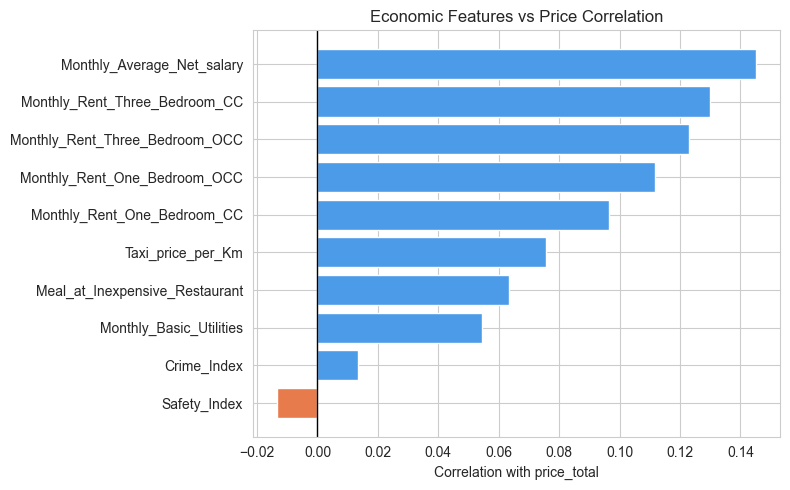

In [24]:
corr_sorted = corr_econ.sort_values()

plt.figure(figsize=(8,5))

plt.barh(
    corr_sorted.index,
    corr_sorted.values,
    color=['#4C9BE8' if x > 0 else '#E87B4C' for x in corr_sorted.values]
)

plt.axvline(0, color='black', linewidth=1)

plt.title("Economic Features vs Price Correlation")
plt.xlabel("Correlation with price_total")

plt.tight_layout()
plt.show()

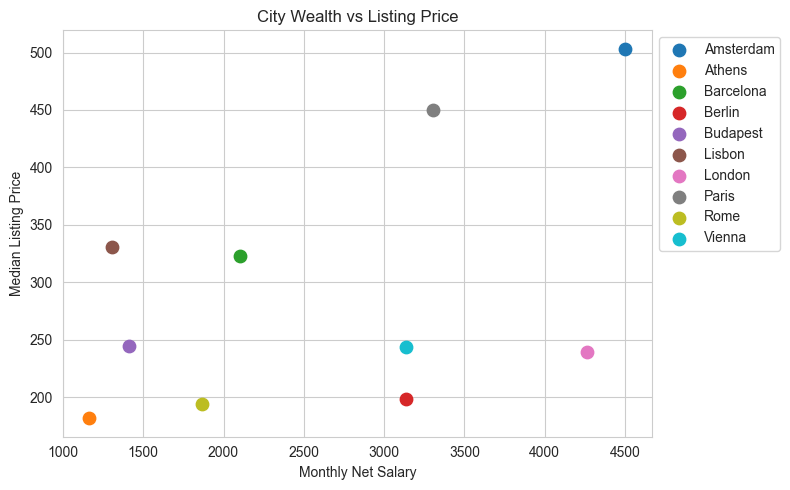

In [25]:
# Scatter: salary vs price
plt.figure(figsize=(8, 5))
for city in df['city'].unique():
    sub = df[df['city'] == city]
    plt.scatter(sub['Monthly_Average_Net_salary'].iloc[0],
                sub['price_total'].median(),
                label=city, s=80)
plt.xlabel('Monthly Net Salary')
plt.ylabel('Median Listing Price')
plt.legend(bbox_to_anchor=(1, 1))
plt.title('City Wealth vs Listing Price')
plt.tight_layout()
plt.show()

In [26]:

num_cols = ['price_total', 'max_guests', 'num_bedrooms',
            'cleanliness_score', 'guest_satisfaction_score',
            'distance_city_center', 'distance_metro',
            'attraction_index', 'restaurant_index', 'proximity_index',
            'Crime_Index', 'Safety_Index', 'Monthly_Average_Net_salary',
            'Monthly_Rent_One_Bedroom_CC']
            

corr = df[num_cols].corr()

# Top features correlated with price
price_corr = corr["price_total"].abs().sort_values(ascending=False).drop("price_total")
print("Top 15 features by |correlation| with price_total:")
print(price_corr.head(15).round(3).to_string())


Top 15 features by |correlation| with price_total:
proximity_index                0.345
attraction_index               0.277
distance_city_center           0.242
restaurant_index               0.228
distance_metro                 0.199
max_guests                     0.191
num_bedrooms                   0.180
Monthly_Average_Net_salary     0.145
Monthly_Rent_One_Bedroom_CC    0.097
Safety_Index                   0.014
Crime_Index                    0.014
cleanliness_score              0.005
guest_satisfaction_score       0.002


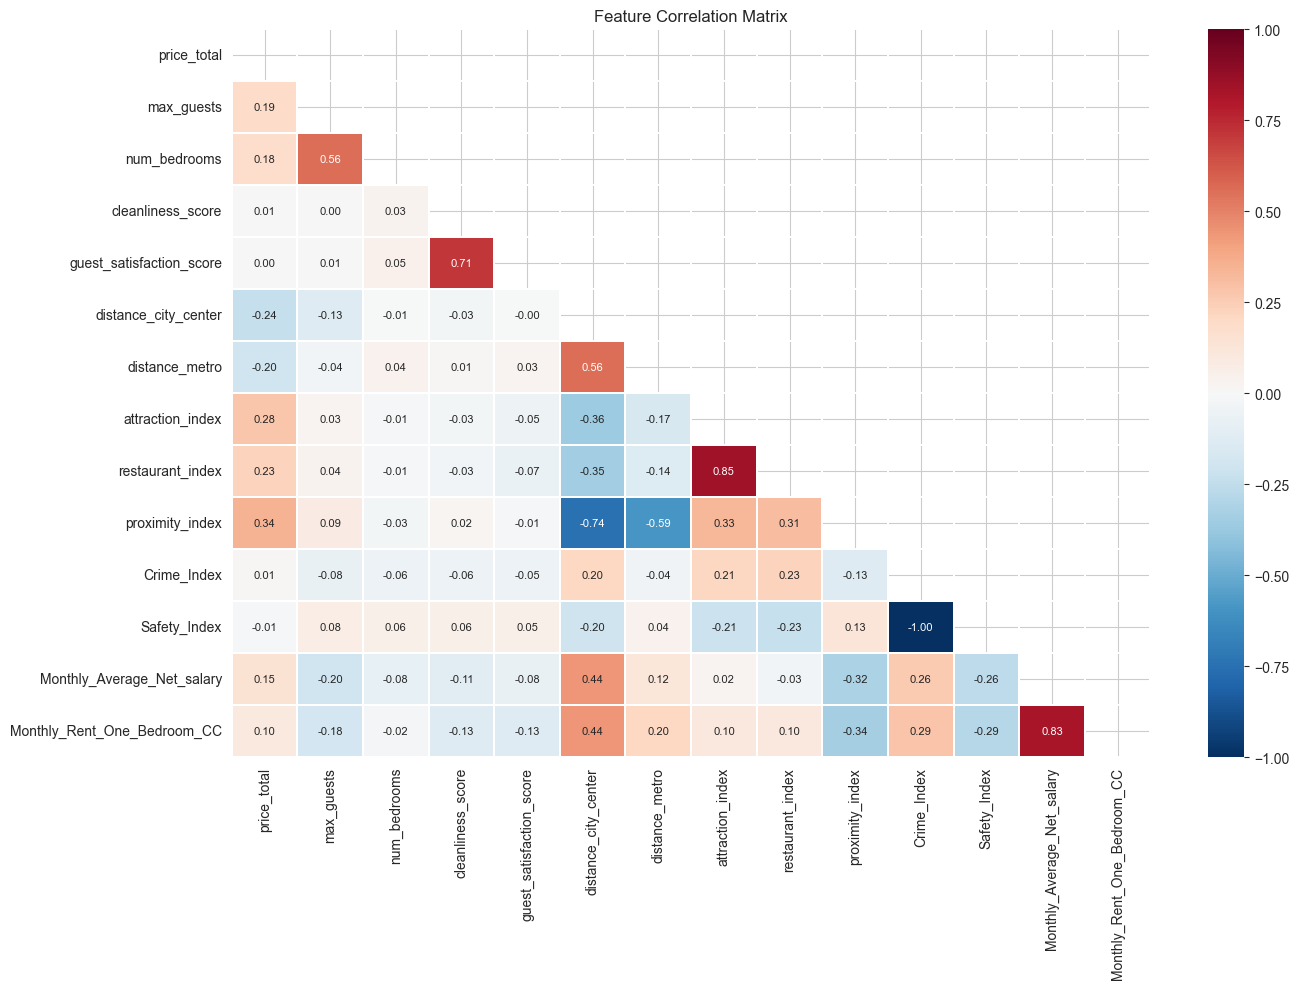

In [27]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Data Preprocessing

In [28]:
print("Dtypes:")
print(df.dtypes.value_counts())

Dtypes:
float64    24
object      7
int64       6
Name: count, dtype: int64


In [29]:
# Drop Redundant Columns
df.drop(columns=[
    'country_name',
    'country_code',       
    'state',              
    'longitude',          
    'latitude',           
    'attraction_index',   
    'restaurant_index',   
], inplace=True, errors='ignore')
 
print(f"Shape after drop: {df.shape}")

Shape after drop: (51707, 30)


In [30]:
# Encoding
for cols in df.select_dtypes(include='object').columns:
    print(f"{cols}: {df[cols].unique()}")
    print(40 * '=')
 
# Binary Encoding
df['day_type'] = df['day_type'].map({'weekday': 0, 'weekend': 1})
 
# Frequency Encoding
freq = df['district'].value_counts() / len(df)
df['district'] = df['district'].map(freq)
 
# Shared(0) < Private(1) < Entire(2)
room_order = {'Shared room': 0, 'Private room': 1, 'Entire home/apt': 2}
df['room_type'] = df['room_type'].map(room_order)
 
city_mean_price = df.groupby('city')['price_log'].mean()
df['city_enc'] = df['city'].map(city_mean_price)
df.drop(columns=['city'], inplace=True)
 
print(f"\nShape after encoding: {df.shape}")
print("Remaining object cols:", df.select_dtypes(include='object').columns.tolist())

room_type: ['Private room' 'Entire home/apt' 'Shared room']
city: ['Amsterdam' 'Athens' 'Barcelona' 'Berlin' 'Budapest' 'Lisbon' 'London'
 'Paris' 'Rome' 'Vienna']
day_type: ['weekday' 'weekend']
district: ['Gemeente Landsmeer' 'Gemeente Amsterdam' 'Gemeente Diemen'
 'Gemeente Zaanstad' 'Gemeente Ouder-Amstel' 'Gemeente Waterland'
 'Gemeente Amstelveen' 'Gemeente Aalsmeer' 'Nomarchia Athinas'
 'Provincia de Barcelona' 'Berlin' 'Budapest' 'Lisbon' 'Loures' 'Oeiras'
 'Almada' 'Odivelas' 'Greater London' 'Paris'
 'Departement des Hauts-de-Seine' 'Departement du Val-de-Marne'
 'Departement de Seine-Saint-Denis' 'Rome'
 'Citta metropolitana di Roma Capitale' 'Wien Stadt'
 'Politischer Bezirk Wien-Umgebung' 'Politischer Bezirk Ganserndorf'
 'Politischer Bezirk Modling' 'Politischer Bezirk Korneuburg']

Shape after encoding: (51707, 30)
Remaining object cols: []


### Feature Scaling

In [31]:
X = df.drop(['price_total', 'price_log'], axis=1)
y = df['price_log']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Outlier clipping
BINARY_COLS = [
    'is_shared_room', 'is_private_room', 'is_superhost',
    'is_multi_listing', 'is_business_listing',
    'day_type',   # 0/1
    'room_type',  # 0/1/2
]
CLIP_COLS = [c for c in X_train.select_dtypes(include=[np.number]).columns
             if c not in BINARY_COLS]
 
for col in CLIP_COLS:
    Q1  = X_train[col].quantile(0.25)
    Q3  = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)  

In [33]:
# StandardScaler 
SCALE_COLS = [
    'max_guests', 'cleanliness_score', 'guest_satisfaction_score',
    'num_bedrooms', 'distance_city_center', 'distance_metro',
    'attraction_index_norm', 'restaurant_index_norm',
    'Crime_Index', 'Safety_Index',
    'Monthly_Average_Net_salary', 'Meal_at_Inexpensive_Restaurant',
    'Taxi_price_per_Km', 'Monthly_Basic_Utilities',
    'Monthly_Rent_One_Bedroom_CC', 'Monthly_Rent_One_Bedroom_OCC',
    'Monthly_Rent_Three_Bedroom_CC', 'Monthly_Rent_Three_Bedroom_OCC',
    'proximity_index',
    'district',   # frequency encoded → continuous
    'city_enc',   # target encoded → continuous
]
SCALE_COLS = [c for c in SCALE_COLS if c in X_train.columns]
 
scaler = StandardScaler()
X_train[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

### Feature Engineering

In [35]:
# Quality Features

X_train['quality_score'] = (
    X_train['cleanliness_score'] * 0.5 +
    X_train['guest_satisfaction_score'] * 0.5
)
X_test['quality_score'] = (
    X_test['cleanliness_score'] * 0.5 +
    X_test['guest_satisfaction_score'] * 0.5
)


X_train['trusted_host'] = (
    (X_train['is_superhost'] == 1) &
    (X_train['guest_satisfaction_score'] > 0)
).astype(int)
X_test['trusted_host'] = (
    (X_test['is_superhost'] == 1) &
    (X_test['guest_satisfaction_score'] > 0)
).astype(int)

print("Quality features done ✓")
print(f"Trusted hosts in train: {X_train['trusted_host'].sum():,} ({X_train['trusted_host'].mean()*100:.1f}%)")


Quality features done ✓
Trusted hosts in train: 14,385 (34.8%)


In [36]:
# Location Features

X_train['location_premium'] = (
    X_train['attraction_index_norm'] * 0.35 +
    X_train['restaurant_index_norm'] * 0.25 +
    X_train['proximity_index']       * 0.25 +
    (-X_train['distance_city_center']) * 0.15   # invert: أقرب = أعلى
)
X_test['location_premium'] = (
    X_test['attraction_index_norm'] * 0.35 +
    X_test['restaurant_index_norm'] * 0.25 +
    X_test['proximity_index']       * 0.25 +
    (-X_test['distance_city_center']) * 0.15
)

X_train['metro_walkable']       = (X_train['distance_metro'] < -0.3).astype(int)
X_train['city_center_walkable'] = (X_train['distance_city_center'] < -0.5).astype(int)
X_test['metro_walkable']        = (X_test['distance_metro'] < -0.3).astype(int)
X_test['city_center_walkable']  = (X_test['distance_city_center'] < -0.5).astype(int)

print("Location features done ✓")
print(f"Metro walkable: {X_train['metro_walkable'].mean()*100:.1f}%")
print(f"City center walkable: {X_train['city_center_walkable'].mean()*100:.1f}%")

Location features done ✓
Metro walkable: 52.5%
City center walkable: 38.3%


In [37]:
# Economic Context Features
X_train['col_index'] = (
    X_train['Meal_at_Inexpensive_Restaurant'] * 0.30 +
    X_train['Monthly_Basic_Utilities']         * 0.30 +
    X_train['Taxi_price_per_Km']               * 0.20 +
    X_train['Monthly_Rent_One_Bedroom_CC']     * 0.20
)
X_test['col_index'] = (
    X_test['Meal_at_Inexpensive_Restaurant'] * 0.30 +
    X_test['Monthly_Basic_Utilities']         * 0.30 +
    X_test['Taxi_price_per_Km']               * 0.20 +
    X_test['Monthly_Rent_One_Bedroom_CC']     * 0.20
)


X_train['guest_bedroom_ratio'] = X_train['max_guests'] / (X_train['num_bedrooms'] + 1)
X_test['guest_bedroom_ratio']  = X_test['max_guests']  / (X_test['num_bedrooms'] + 1)

print("Economic features done ✓")

Economic features done ✓


In [38]:
# Dynamic Pricing Signals

# weekend × location premium 
X_train['weekend_x_location'] = X_train['day_type'] * X_train['location_premium']
X_test['weekend_x_location']  = X_test['day_type']  * X_test['location_premium']

# Weekend × Quality interaction
X_train['weekend_x_quality'] = X_train['day_type'] * X_train['quality_score']
X_test['weekend_x_quality']  = X_test['day_type']  * X_test['quality_score']

# Weekend × Superhost
X_train['weekend_x_superhost'] = X_train['day_type'] * X_train['is_superhost']
X_test['weekend_x_superhost']  = X_test['day_type']  * X_test['is_superhost']

# City Weekend Premium
X_train['city_weekend_premium'] = X_train['city_enc'] * X_train['day_type']
X_test['city_weekend_premium']  = X_test['city_enc']  * X_test['day_type']


print("Dynamic pricing features done ✓")
print(f"New features added: quality_score, trusted_host, location_premium,")
print(f"  metro_walkable, city_center_walkable, col_index, guest_bedroom_ratio,")
print(f"  weekend_x_location, weekend_x_quality, weekend_x_superhost, city_weekend_premium")
print(f"X_train shape: {X_train.shape}")

Dynamic pricing features done ✓
New features added: quality_score, trusted_host, location_premium,
  metro_walkable, city_center_walkable, col_index, guest_bedroom_ratio,
  weekend_x_location, weekend_x_quality, weekend_x_superhost, city_weekend_premium
X_train shape: (41365, 39)


In [39]:
print(f"Total features after engineering: {X_train.shape[1]}")
print(f"  Original features : 28")
print(f"  New features added: {X_train.shape[1] - 28}")
print()
print("All features:")
for i, c in enumerate(X_train.columns, 1):
    tag = " ← NEW" if c in ["quality_score","trusted_host","location_premium",
                              "metro_walkable","city_center_walkable","col_index",
                              "guest_bedroom_ratio","weekend_x_location",
                              "weekend_x_quality","weekend_x_superhost",
                              "city_weekend_premium"] else ""
    print(f"  {i:2d}. {c}{tag}")

Total features after engineering: 39
  Original features : 28
  New features added: 11

All features:
   1. room_type
   2. is_shared_room
   3. is_private_room
   4. max_guests
   5. is_superhost
   6. is_multi_listing
   7. is_business_listing
   8. cleanliness_score
   9. guest_satisfaction_score
  10. num_bedrooms
  11. distance_city_center
  12. distance_metro
  13. attraction_index_norm
  14. restaurant_index_norm
  15. day_type
  16. district
  17. Crime_Index
  18. Safety_Index
  19. Monthly_Average_Net_salary
  20. Meal_at_Inexpensive_Restaurant
  21. Taxi_price_per_Km
  22. Monthly_Basic_Utilities
  23. Monthly_Rent_One_Bedroom_CC
  24. Monthly_Rent_One_Bedroom_OCC
  25. Monthly_Rent_Three_Bedroom_CC
  26. Monthly_Rent_Three_Bedroom_OCC
  27. proximity_index
  28. city_enc
  29. quality_score ← NEW
  30. trusted_host ← NEW
  31. location_premium ← NEW
  32. metro_walkable ← NEW
  33. city_center_walkable ← NEW
  34. col_index ← NEW
  35. guest_bedroom_ratio ← NEW
  36. weeken

In [40]:
# Variance Threshold 
vt = VarianceThreshold(threshold=0.001)
vt.fit(X_train)
low_var = [c for c, k in zip(X_train.columns, vt.get_support()) if not k]
print(f"Low-variance features: {low_var if low_var else 'None — all OK ✓'}")

Low-variance features: ['num_bedrooms']


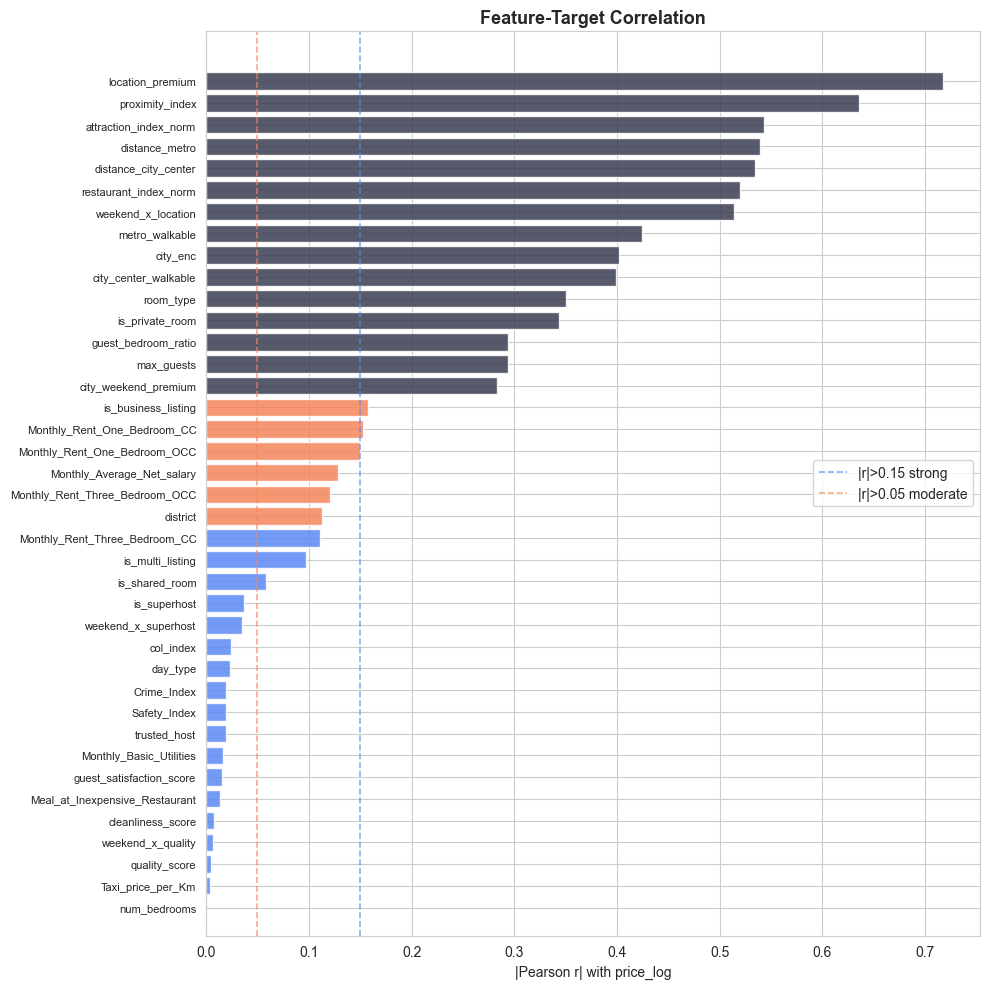

Top 15 by correlation:
location_premium         0.7174
proximity_index          0.6354
attraction_index_norm    0.5432
distance_metro           0.5391
distance_city_center     0.5344
restaurant_index_norm    0.5198
weekend_x_location       0.5135
metro_walkable           0.4244
city_enc                 0.4017
city_center_walkable     0.3992
room_type                0.3504
is_private_room          0.3434
guest_bedroom_ratio      0.2942
max_guests               0.2942
city_weekend_premium     0.2830


In [41]:
# Correlation with target
corr_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
colors = ["#5B8AF5" if v > 0.15 else "#F5855B" if v > 0.05 else "#3A3D50"
          for v in corr_target.values[::-1]]
plt.barh(range(len(corr_target)), corr_target.values[::-1],
         color=colors[::-1], alpha=0.85)
plt.yticks(range(len(corr_target)), corr_target.index[::-1], fontsize=8)
plt.axvline(0.15, color="#5B8AF5", lw=1.2, ls="--", alpha=0.7, label="|r|>0.15 strong")
plt.axvline(0.05, color="#F5855B", lw=1.2, ls="--", alpha=0.7, label="|r|>0.05 moderate")
plt.xlabel("|Pearson r| with price_log")
plt.title("Feature-Target Correlation", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 15 by correlation:")
print(corr_target.head(15).round(4).to_string())

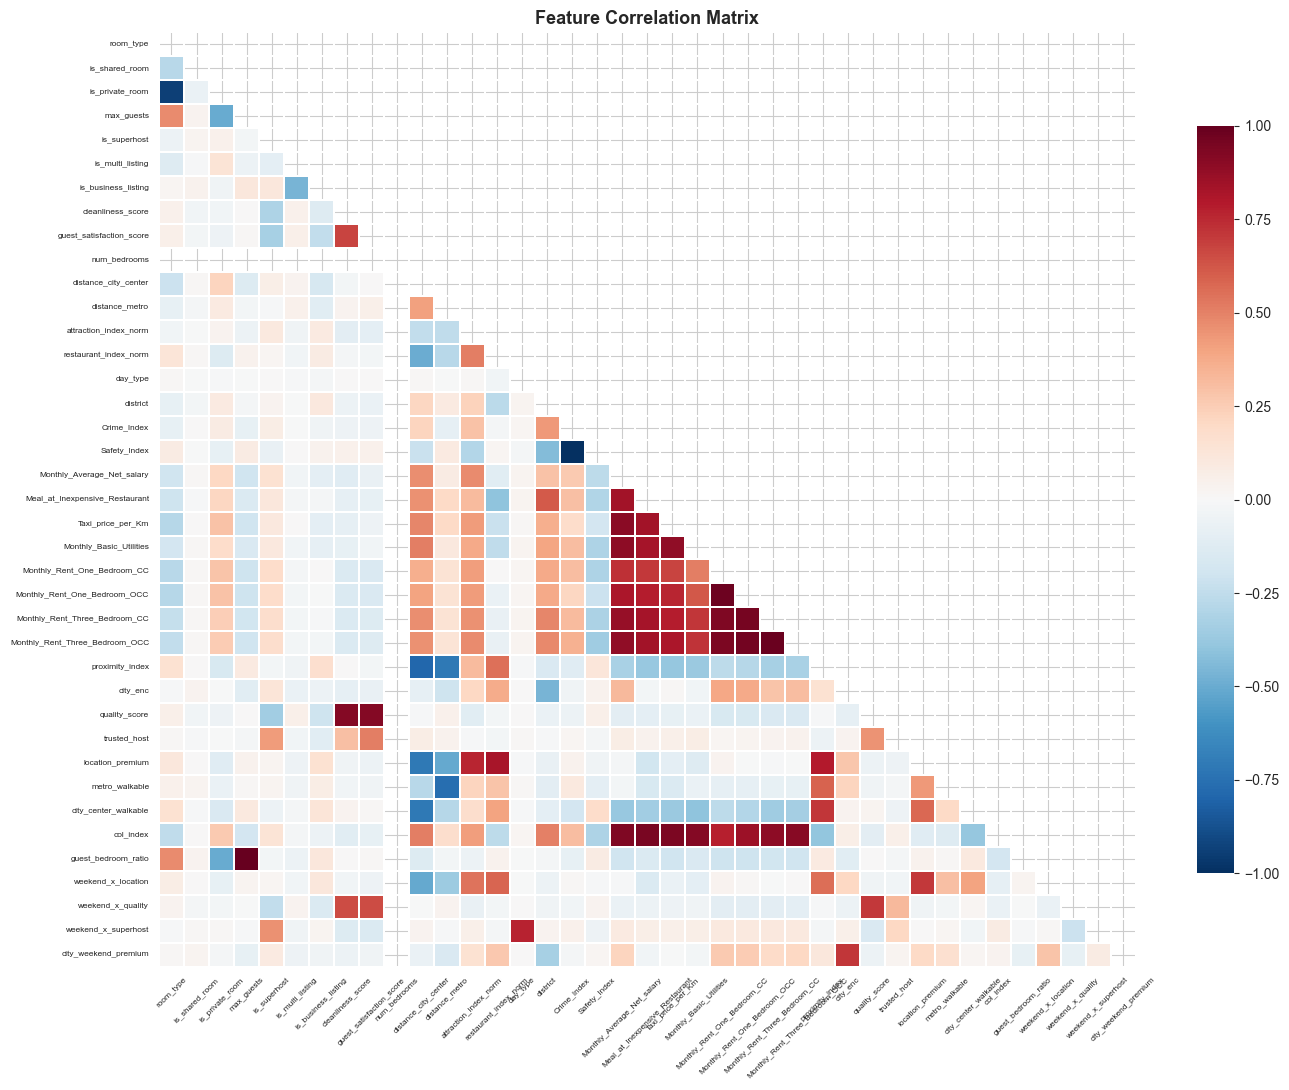

Highly correlated pairs (|r|>0.90): 16
  Safety_Index                   <-> Crime_Index                     r=1.000
  guest_bedroom_ratio            <-> max_guests                      r=1.000
  Monthly_Rent_Three_Bedroom_OCC <-> Monthly_Rent_Three_Bedroom_CC   r=0.990
  Monthly_Rent_One_Bedroom_OCC   <-> Monthly_Rent_One_Bedroom_CC     r=0.978
  Monthly_Rent_Three_Bedroom_OCC <-> Monthly_Rent_One_Bedroom_OCC    r=0.965
  Monthly_Rent_Three_Bedroom_CC  <-> Monthly_Rent_One_Bedroom_OCC    r=0.960
  col_index                      <-> Meal_at_Inexpensive_Restaurant  r=0.949
  Monthly_Rent_Three_Bedroom_OCC <-> Monthly_Rent_One_Bedroom_CC     r=0.945
  col_index                      <-> Taxi_price_per_Km               r=0.943
  is_private_room                <-> room_type                       r=0.942


In [42]:
# Correlation Heatmap (multicollinearity) ───────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = X_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.2,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", labelsize=6, rotation=45)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

# High corr pairs
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(c,r,upper.loc[r,c]) for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r,c]) and upper.loc[r,c] > 0.90]
high_corr = sorted(high_corr, key=lambda x:-x[2])
print(f"Highly correlated pairs (|r|>0.90): {len(high_corr)}")
for a,b,r in high_corr[:10]:
    print(f"  {a:30s} <-> {b:30s}  r={r:.3f}")


In [43]:
# Drop highly correlated duplicates
CORR_DROP = []
for a, b, r in high_corr:
    if r > 0.95:
        if a not in CORR_DROP and b not in CORR_DROP:
            keep   = a if corr_target.get(a, 0) >= corr_target.get(b, 0) else b
            remove = b if keep == a else a
            CORR_DROP.append(remove)

if CORR_DROP:
    X_train.drop(columns=CORR_DROP, inplace=True, errors="ignore")
    X_test.drop(columns=CORR_DROP,  inplace=True, errors="ignore")
    print(f"Dropped {len(CORR_DROP)} highly correlated: {CORR_DROP}")
else:
    print("No features dropped from correlation filter ✓")
print(f"Shape: {X_train.shape}")


Dropped 4 highly correlated: ['Safety_Index', 'max_guests', 'Monthly_Rent_Three_Bedroom_CC', 'Monthly_Rent_One_Bedroom_OCC']
Shape: (41365, 35)


In [44]:
# ── 4. Random Forest Importance ──────────────────────────────
rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
r2_tr  = rf.score(X_train, y_train)
r2_te  = rf.score(X_test,  y_test)

print(f"RF R² — train: {r2_tr:.4f}  |  test: {r2_te:.4f}")
print("Feature importances:")
print(rf_imp.round(4).to_string())


RF R² — train: 0.9133  |  test: 0.8670
Feature importances:
location_premium                  0.4828
proximity_index                   0.1601
Monthly_Rent_One_Bedroom_CC       0.0700
room_type                         0.0684
guest_bedroom_ratio               0.0484
distance_city_center              0.0201
attraction_index_norm             0.0195
distance_metro                    0.0180
city_enc                          0.0167
restaurant_index_norm             0.0132
Monthly_Average_Net_salary        0.0102
Monthly_Rent_Three_Bedroom_OCC    0.0094
quality_score                     0.0092
col_index                         0.0073
Taxi_price_per_Km                 0.0069
guest_satisfaction_score          0.0069
Crime_Index                       0.0054
district                          0.0050
Meal_at_Inexpensive_Restaurant    0.0033
Monthly_Basic_Utilities           0.0033
weekend_x_location                0.0026
weekend_x_quality                 0.0024
is_private_room                   0.00

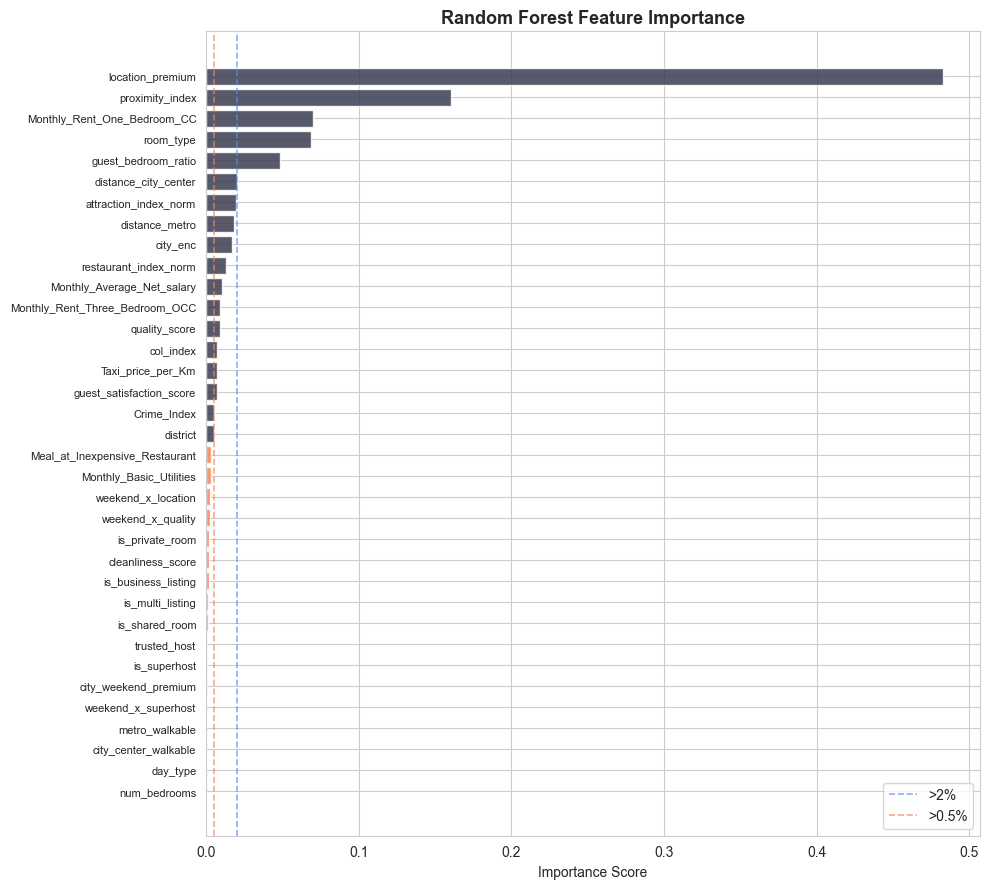

In [45]:
plt.figure(figsize=(10, 9))
colors = ["#5B8AF5" if v >= 0.02 else "#F5855B" if v >= 0.005 else "#3A3D50"
          for v in rf_imp.values[::-1]]
plt.barh(range(len(rf_imp)), rf_imp.values[::-1], color=colors[::-1], alpha=0.85)
plt.yticks(range(len(rf_imp)), rf_imp.index[::-1], fontsize=8)
plt.axvline(0.02,  color="#5B8AF5", lw=1.2, ls="--", alpha=0.7, label=">2%")
plt.axvline(0.005, color="#F5855B", lw=1.2, ls="--", alpha=0.7, label=">0.5%")
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importance", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
# Lasso (L1) 
lasso = LassoCV(cv=5, random_state=42, max_iter=2000, n_jobs=-1)
lasso.fit(X_train, y_train)

lasso_coef = pd.Series(np.abs(lasso.coef_), index=X_train.columns).sort_values(ascending=False)
lasso_zero = lasso_coef[lasso_coef == 0].index.tolist()

print(f"Best alpha: {lasso.alpha_:.5f}")
print(f"Zeroed features ({len(lasso_zero)}): {lasso_zero}")
print("Top non-zero coefficients:")
print(lasso_coef[lasso_coef > 0].head(20).round(4).to_string())


Best alpha: 0.00049
Zeroed features (3): ['num_bedrooms', 'col_index', 'weekend_x_superhost']
Top non-zero coefficients:
Monthly_Rent_One_Bedroom_CC       0.5240
Monthly_Rent_Three_Bedroom_OCC    0.5032
room_type                         0.3955
Monthly_Average_Net_salary        0.3493
proximity_index                   0.1961
distance_metro                    0.1873
guest_bedroom_ratio               0.1686
distance_city_center              0.1663
attraction_index_norm             0.1347
is_business_listing               0.0945
Meal_at_Inexpensive_Restaurant    0.0857
district                          0.0840
trusted_host                      0.0671
restaurant_index_norm             0.0502
is_superhost                      0.0393
is_multi_listing                  0.0375
metro_walkable                    0.0335
cleanliness_score                 0.0331
Monthly_Basic_Utilities           0.0295
day_type                          0.0286


In [48]:
# Voting-Based Final Selection
corr_top   = set(corr_target.head(int(len(corr_target) * 0.65)).index)
rf_top     = set(rf_imp[rf_imp >= 0.005].index)
lasso_keep = set(lasso_coef[lasso_coef > 0].index)

votes = {f: sum([f in corr_top, f in rf_top, f in lasso_keep])
         for f in X_train.columns}

votes_df = pd.DataFrame.from_dict(votes, orient="index", columns=["votes"])
votes_df["Corr"]  = ["✓" if f in corr_top   else "✗" for f in votes_df.index]
votes_df["RF"]    = ["✓" if f in rf_top     else "✗" for f in votes_df.index]
votes_df["Lasso"] = ["✓" if f in lasso_keep else "✗" for f in votes_df.index]
votes_df = votes_df.sort_values("votes", ascending=False)

print("Voting table:")
print(votes_df.to_string())


Voting table:
                                votes Corr RF Lasso
room_type                           3    ✓  ✓     ✓
distance_metro                      3    ✓  ✓     ✓
distance_city_center                3    ✓  ✓     ✓
city_enc                            3    ✓  ✓     ✓
location_premium                    3    ✓  ✓     ✓
restaurant_index_norm               3    ✓  ✓     ✓
attraction_index_norm               3    ✓  ✓     ✓
Monthly_Average_Net_salary          3    ✓  ✓     ✓
proximity_index                     3    ✓  ✓     ✓
Monthly_Rent_Three_Bedroom_OCC      3    ✓  ✓     ✓
Monthly_Rent_One_Bedroom_CC         3    ✓  ✓     ✓
guest_bedroom_ratio                 3    ✓  ✓     ✓
is_shared_room                      2    ✓  ✗     ✓
is_private_room                     2    ✓  ✗     ✓
Crime_Index                         2    ✗  ✓     ✓
Taxi_price_per_Km                   2    ✗  ✓     ✓
guest_satisfaction_score            2    ✗  ✓     ✓
is_superhost                        2    ✓  ✗     

In [50]:
# FINAL FEATURES
FINAL_FEATURES = [f for f, v in votes.items() if v >= 2]
FINAL_FEATURES = sorted(FINAL_FEATURES, key=lambda f: -rf_imp.get(f, 0))

print(f"FINAL SELECTED: {len(FINAL_FEATURES)} features")
for i, f in enumerate(FINAL_FEATURES, 1):
    v = votes[f]
    print(f"  {i:2d}. {f:40s}  votes={v}")

X_train_final = X_train[FINAL_FEATURES].copy()
X_test_final  = X_test[FINAL_FEATURES].copy()

print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final : {X_test_final.shape}")


FINAL SELECTED: 26 features
   1. location_premium                          votes=3
   2. proximity_index                           votes=3
   3. Monthly_Rent_One_Bedroom_CC               votes=3
   4. room_type                                 votes=3
   5. guest_bedroom_ratio                       votes=3
   6. distance_city_center                      votes=3
   7. attraction_index_norm                     votes=3
   8. distance_metro                            votes=3
   9. city_enc                                  votes=3
  10. restaurant_index_norm                     votes=3
  11. Monthly_Average_Net_salary                votes=3
  12. Monthly_Rent_Three_Bedroom_OCC            votes=3
  13. quality_score                             votes=2
  14. Taxi_price_per_Km                         votes=2
  15. guest_satisfaction_score                  votes=2
  16. Crime_Index                               votes=2
  17. district                                  votes=2
  18. weekend_x_loca